# Load, batch, and checkpoint order with Grain

CPU companion; no accelerator is required. TPU execution not validated.

- Build a Grain source/sampler/batch pipeline and verify its record order.
- Restore the next-read boundary rather than restarting from a seed.
- Check each epoch coverage independently.
- Distinguish tested serial iteration from unmeasured worker/prefetch performance.

Now that you can check example order yourself, let’s use Grain to manage the input pipeline. We’ll shuffle two small epochs, batch the records, save the iterator position, and replay the next batch. Using zero worker processes keeps the sequence easy to inspect; this exercise does not measure prefetch speed.

## The idea

Grain separates source lookup, sampler ordering, transformations and iteration. A DataLoader combines these choices, while its iterator owns the consumed position. Rebuilding a loader from the same seed starts over; restoring a compatible iterator snapshot resumes from the saved boundary.

## Map a record key to a testable source

TutorialSource implements len and indexing. A request for key i returns the same $\mathrm{id}=i$, $x=i/10$ and $y=2x-1$. Its repr includes a version and count because the iterator state records its source configuration. No file I/O, decoder or download is hidden in this example.

In a real corpus, a source key must remain associated with the same record revision. A human-readable repr is only a basic compatibility check; preserve a dataset revision or digest separately. Changing the underlying values without changing the source identity can defeat a cursor restore even if record counts match.

## Follow the sampler-to-batch boundary

IndexSampler chooses record keys over two epochs from a fixed seed. DataLoader reads them and applies `Batch(4)`. The ID vector is the evidence of actual record order after these operations; feature shapes alone would not tell you whether the order changed.

We have twelve records, so one epoch contains exactly three full batches. operations order matters: per-example transforms normally precede batching, while a batch transform receives grouped values. Keep an independent relation check on labels to verify that transforms did not break alignment.

```text
IndexSampler → record keys → TutorialSource[key]
             → Batch(4) → iterator → {id[4],x[4],y[4]}
```

## Snapshot the iterator after consumption

After `next(iterator)` returns the first batch, get_state captures the next-read boundary. We read the second batch as our expected future. A fresh iterator receives `set_state(snapshot)`, then next returns that same second batch. Saving before the first batch would repeat it; saving after the second would skip it on a restore intended for the first boundary.

The snapshot is opaque bytes. Let Grain interpret it rather than editing its internal fields. The two iterators must use compatible sampler, source and worker configuration. The practical check compares all three fields, not only IDs, so deterministic order cannot hide changed content.

## Worker and buffer settings are workload choices

`worker_count=0` runs in the current process and is convenient for debugging or notebook execution. With workers enabled, decoding/transformation can run in child processes and buffer outputs; top-level source and transform classes must be serializable, and a main guard is important in standalone multiprocessing scripts. The code here deliberately does not start workers.

Prefetching can overlap preparation and consumption, but its benefit depends on storage, transform cost, device demand and memory use. Changing workers or buffers is a new configuration to validate and measure. Do not infer that this small in-memory source needs prefetching, or claim a pipeline speedup without a representative synchronized workload.

## Prepare the data and state

Create main.py in your course workspace. Use the tested course environment and add this block first.

In [1]:
import numpy as np
import grain.python as grain
class TutorialSource:
    def __init__(self,count=12):
        self.count = count
    def __len__(self):
        return self.count
    def __getitem__(self,index):
        value = np.float32(index/10)
        return {"id":np.int64(index),"x":value,"y":np.float32(2*value-1)}
    def __repr__(self):
        return f"TutorialSource(v1,n={self.count})"
def make_loader(seed=42,batch_size=4,count=12,drop_remainder=False):
    return grain.DataLoader(
        data_source=TutorialSource(count),
        sampler=grain.IndexSampler(num_records=count,num_epochs=2,shuffle=True,seed=seed),
        operations=[grain.Batch(batch_size,drop_remainder=drop_remainder)],
        worker_count=0)

This setup makes the dataset and software assumptions explicit. No external dataset or accelerator is required.

## Build the pipeline or state transition

Append this block to the same file; follow the named state objects through each function.

In [2]:
loader = make_loader()
iterator = iter(loader)
first_batch = next(iterator)
snapshot = iterator.get_state()
second_batch = next(iterator)
restored_iterator = iter(make_loader())
restored_iterator.set_state(snapshot)
replayed_batch = next(restored_iterator)

The function boundaries expose which inputs determine the next output and which state must be preserved.

## Run the comparison

Append the checks, save main.py and run python main.py. Predict what should agree before running.

In [3]:
np.testing.assert_array_equal(second_batch["id"],replayed_batch["id"])
for key in ("x","y"):
    np.testing.assert_array_equal(second_batch[key],replayed_batch[key])
for batch in (first_batch,second_batch):
    np.testing.assert_allclose(batch["y"],2*batch["x"]-1,atol=1e-7)
one_epoch = list(make_loader())[:3]
np.testing.assert_array_equal(np.sort(np.concatenate([b["id"] for b in one_epoch])),np.arange(12))
print("First IDs:",first_batch["id"].tolist())
print("Next IDs:",second_batch["id"].tolist())
print("Iterator state bytes:",len(snapshot))
print("Restored next batch matches")

First IDs: [8, 6, 7, 9]
Next IDs: [0, 5, 1, 2]
Iterator state bytes: 329
Restored next batch matches


The comparison checks the next behavior, not merely whether a save call succeeded.

## Run the example

In [4]:
import numpy as np
import grain.python as grain
class TutorialSource:
    def __init__(self,count=12):
        self.count = count
    def __len__(self):
        return self.count
    def __getitem__(self,index):
        value = np.float32(index/10)
        return {"id":np.int64(index),"x":value,"y":np.float32(2*value-1)}
    def __repr__(self):
        return f"TutorialSource(v1,n={self.count})"
def make_loader(seed=42,batch_size=4,count=12,drop_remainder=False):
    return grain.DataLoader(
        data_source=TutorialSource(count),
        sampler=grain.IndexSampler(num_records=count,num_epochs=2,shuffle=True,seed=seed),
        operations=[grain.Batch(batch_size,drop_remainder=drop_remainder)],
        worker_count=0)

loader = make_loader()
iterator = iter(loader)
first_batch = next(iterator)
snapshot = iterator.get_state()
second_batch = next(iterator)
restored_iterator = iter(make_loader())
restored_iterator.set_state(snapshot)
replayed_batch = next(restored_iterator)

np.testing.assert_array_equal(second_batch["id"],replayed_batch["id"])
for key in ("x","y"):
    np.testing.assert_array_equal(second_batch[key],replayed_batch[key])
for batch in (first_batch,second_batch):
    np.testing.assert_allclose(batch["y"],2*batch["x"]-1,atol=1e-7)
one_epoch = list(make_loader())[:3]
np.testing.assert_array_equal(np.sort(np.concatenate([b["id"] for b in one_epoch])),np.arange(12))
print("First IDs:",first_batch["id"].tolist())
print("Next IDs:",second_batch["id"].tolist())
print("Iterator state bytes:",len(snapshot))
print("Restored next batch matches")

First IDs: [8, 6, 7, 9]
Next IDs: [0, 5, 1, 2]
Iterator state bytes: 329
Restored next batch matches


Expected: The restored next IDs, features and labels match. One epoch contains twelve unique IDs. Exact shuffled order is determined by tested Grain version/configuration.

## Restoring the iterator repeats the next batch

Predict: Does the restored sequence start at the first batch again?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
visual_data = {'kind': 'bar', 'labels': ['slot 0', 'slot 1', 'slot 2', 'slot 3'], 'ylabel': 'example ID', 'series': [{'label': 'first batch', 'y': first_batch['id'].tolist()}, {'label': 'next batch', 'y': second_batch['id'].tolist()}, {'label': 'restored next', 'y': replayed_batch['id'].tolist()}]}

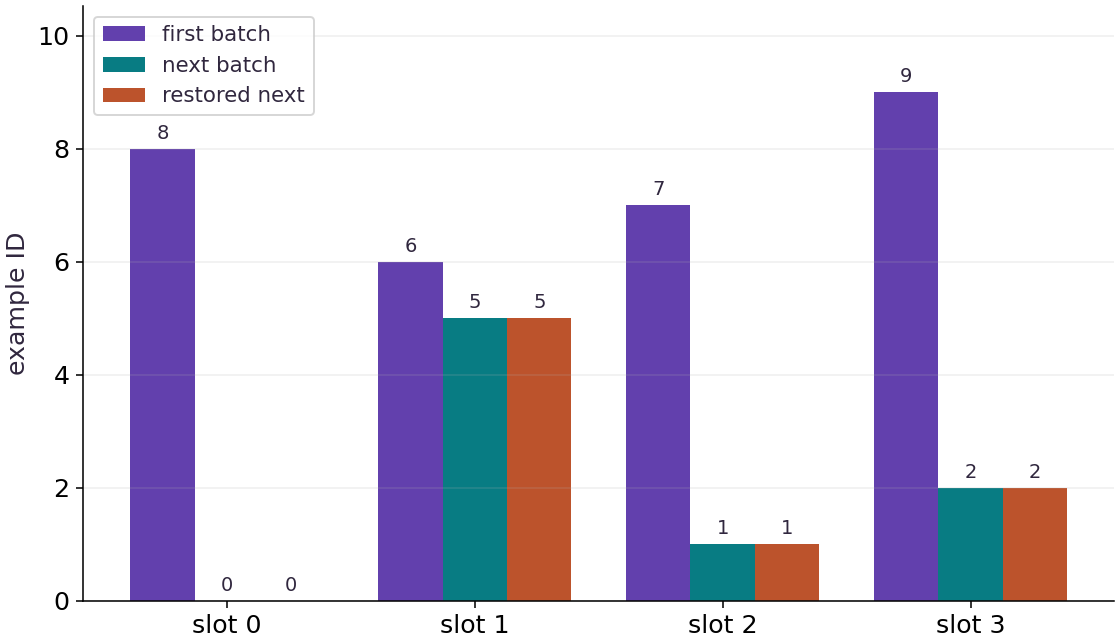

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data['unit'] in ('attention weight', 'next-token probability'):
            kw.update(vmin=0, vmax=1)
        device_ids = 'device ID' in data['unit']
        if device_ids:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            ids=np.unique(a).astype(int)
            kw.update(cmap=ListedColormap(palette[:len(ids)]), norm=BoundaryNorm(np.arange(ids.min()-0.5,ids.max()+1.5),len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if device_ids else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

Each group is a slot within a batch, and bar height gives the example ID in that slot. Compare the “next batch” and “restored next” bars beside one another: their heights match at every slot. They are adjacent bars, not overlapping curves.

The first batch contains $(8,6,7,9)$. The uninterrupted next batch contains $(0,5,1,2)$, and the restored iterator produces that same sequence. The zero-height bars in the first slot represent example ID $0$; they are not missing data.

### Connect it to the computation

The checkpoint captures the iterator after the first batch. Restoring it therefore resumes at the next batch, rather than replaying the first one. Equal IDs in the same slots establish that both membership and ordering agree at this boundary.

IDs are labels, so a taller bar does not indicate a larger input value or a better batch. This comparison verifies the next batch only. To establish a complete training restart, also restore the matching model, optimizer, random state, and dataset configuration, then compare the next update.

## A fresh iterator restarts

Predict: If you use the same seed but do not restore state, which batch arrives next?

In [7]:
fresh_first = next(iter(make_loader()))
np.testing.assert_array_equal(fresh_first["id"],first_batch["id"])
assert not np.array_equal(fresh_first["id"],second_batch["id"])
print("Same seed restarts; it does not resume")

Same seed restarts; it does not resume


Expected: The first batch repeats, rather than replaying the saved next batch.

The seed fixes ordering. Position is separate state.

## Audit both epochs

Predict: Predict total record count and uniqueness per epoch.

In [8]:
two_epochs = list(make_loader())
assert len(two_epochs)==6
for start in (0,3):
    values = np.concatenate([b["id"] for b in two_epochs[start:start+3]])
    np.testing.assert_array_equal(np.sort(values),np.arange(12))
print("Each epoch covers all twelve IDs")

Each epoch covers all twelve IDs


Expected: Six batches; each set of three covers twelve records exactly once.

Across epochs, repeated IDs are intentional. Check coverage at the correct epoch boundary instead of treating every repeat as a bug.

## Your exercise

Consume two batches, snapshot, and replay the third batch with a new compatible iterator.

In [9]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [10]:
later = iter(make_loader())
next(later);next(later)
later_state = later.get_state()
expected_third = next(later)
new_iterator = iter(make_loader());new_iterator.set_state(later_state)
np.testing.assert_array_equal(next(new_iterator)["id"],expected_third["id"])

## Replay through an epoch boundary · Transfer

Save the iterator after the third batch and compare the next two batches with a fresh restored iterator. Check IDs and values. Explain why reproducing only the last batch of one epoch is not sufficient.

Hint: The loader has two epochs; the fourth and fifth batches belong to the next epoch.

In [11]:
# Write your attempt here.

## Reference reasoning

An epoch boundary changes the sampling context. Testing across it checks more of the iterator contract than replaying one batch inside an epoch.

In [12]:
boundary=iter(make_loader())
for _ in range(3):next(boundary)
boundary_state=boundary.get_state()
expected=[next(boundary) for _ in range(2)]
replay=iter(make_loader());replay.set_state(boundary_state)
for reference in expected:
    actual=next(replay)
    for name in ('id','x','y'):np.testing.assert_array_equal(actual[name],reference[name])
print('Next-epoch IDs replayed:',[b['id'].tolist() for b in expected])

Next-epoch IDs replayed: [[2, 0, 11, 1], [5, 7, 6, 8]]


## Reject a changed sampler · Challenge

Try restoring the original snapshot into a loader with a different seed. Capture the compatibility error, then rebuild the matching loader.

Hint: Read the restore diagnostic; changing the seed changes sampler identity.

In [13]:
# Write your attempt here.

## Reference reasoning

A snapshot cannot be assumed to apply to a different ordering configuration. Recreate the same pipeline configuration before restoring; explicit version/data identity checks remain necessary.

In [14]:
incompatible = iter(make_loader(seed=99))
try:
    incompatible.set_state(snapshot)
except ValueError:
    print("Expected sampler compatibility rejection")
else:
    raise AssertionError("Expected changed sampler rejection")
compatible = iter(make_loader(seed=42));compatible.set_state(snapshot)
np.testing.assert_array_equal(next(compatible)["id"],second_batch["id"])

Expected sampler compatibility rejection


## Checkpoint

What makes a fresh loader resume at the saved next batch?

1. Only using the original seed.
2. Restoring compatible iterator state after rebuilding its source/sampler configuration.
3. Calling next once regardless of checkpoint position.

## Diagnose

A snapshot cannot be assumed to apply to a different ordering configuration. Recreate the same pipeline configuration before restoring; explicit version/data identity checks remain necessary.

## Evidence

Keep Grain sampler configuration and exact example IDs for full and partial batches; save iterator bytes, recreate the loader, and compare the next batch before/after restore. Record the incompatible configuration failure.

## Carry forward

- Map a record key to a testable source
- Follow the sampler-to-batch boundary
- Snapshot the iterator after consumption
- Worker and buffer settings are workload choices

## Primary references

- [NumPy Generator permutation](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.permutation.html)
- [Grain DataLoader guide](https://google-grain.readthedocs.io/en/latest/tutorials/data_loader_tutorial.html)